In [1]:
# ============================================================
# PYTHON TASK 1: PRICE ELASTICITY / RETURN PROBABILITY ANALYSIS
# Project: E-Commerce Profitability & Return Optimization Engine
#
# Dataset limitation:
# Discount percentage is unavailable.
# Therefore, Price is analyzed against Return Probability.
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

file_path = r"C:\Users\91934\OneDrive\Desktop\DA\PROJECT\data\Sales Transaction.csv"

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (536350, 8)


,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12-09-2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,12-09-2019,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,12-09-2019,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,12-09-2019,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,12-09-2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom


In [2]:
df.info()

print("\nColumns:")
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionNo  536350 non-null  object 
 1   Date           536350 non-null  object 
 2   ProductNo      536350 non-null  object 
 3   ProductName    536350 non-null  object 
 4   Price          536350 non-null  float64
 5   Quantity       536350 non-null  int64  
 6   CustomerNo     536295 non-null  float64
 7   Country        536350 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.7+ MB

Columns:
['TransactionNo', 'Date', 'ProductNo', 'ProductName', 'Price', 'Quantity', 'CustomerNo', 'Country']


In [3]:
print("Missing Values:")

print(df.isnull().sum())

Missing Values:
TransactionNo     0
Date              0
ProductNo         0
ProductName       0
Price             0
Quantity          0
CustomerNo       55
Country           0
dtype: int64


In [4]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 5200


In [5]:
df["Is_Returned"] = (
    df["TransactionNo"]
    .astype(str)
    .str.startswith("C")
    .astype(int)
)

df[["TransactionNo", "Is_Returned"]].head(10)


,TransactionNo,Is_Returned
0,581482,0
1,581475,0
2,581475,0
3,581475,0
4,581475,0
5,581475,0
6,581475,0
7,581475,0
8,581475,0
9,581475,0


In [6]:
return_summary = df["Is_Returned"].value_counts()

print(return_summary)

print(
    "Overall Return Rate:",
    round(df["Is_Returned"].mean() * 100, 2),
    "%"
)

Is_Returned
0    527765
1      8585
Name: count, dtype: int64
Overall Return Rate: 1.6 %


In [7]:
df["Price"] = pd.to_numeric(
    df["Price"],
    errors="coerce"
)

df = df[df["Price"] > 0].copy()

In [8]:
price_bins = [
    0,
    5,
    10,
    20,
    50,
    100,
    float("inf")
]

price_labels = [
    "0-5",
    "5-10",
    "10-20",
    "20-50",
    "50-100",
    "100+"
]

df["Price_Range"] = pd.cut(
    df["Price"],
    bins=price_bins,
    labels=price_labels,
    right=False
)

In [9]:
price_analysis = (
    df.groupby(
        "Price_Range",
        observed=False
    )
    .agg(
        Total_Transactions=("TransactionNo", "count"),
        Returned_Transactions=("Is_Returned", "sum"),
        Return_Probability=("Is_Returned", "mean")
    )
    .reset_index()
)

price_analysis["Return_Rate_Percentage"] = (
    price_analysis["Return_Probability"] * 100
)

print(price_analysis)

  Price_Range  Total_Transactions  Returned_Transactions  Return_Probability  \
0         0-5                   0                      0                 NaN   
1        5-10               79085                   1004            0.012695   
2       10-20              431139                   6706            0.015554   
3       20-50               25694                    831            0.032342   
4      50-100                 296                     26            0.087838   
5        100+                 136                     18            0.132353   

   Return_Rate_Percentage  
0                     NaN  
1                1.269520  
2                1.555415  
3                3.234218  
4                8.783784  
5               13.235294  


In [10]:
breaking_point = price_analysis.loc[
    price_analysis["Return_Probability"].idxmax()
]

print("\nHighest Return Probability Price Range:")

print("Price Range:", breaking_point["Price_Range"])

print(
    "Return Rate:",
    round(
        breaking_point["Return_Rate_Percentage"],
        2
    ),
    "%"
)


Highest Return Probability Price Range:
Price Range: 100+
Return Rate: 13.24 %


In [11]:
correlation = df[
    ["Price", "Is_Returned"]
].corr().loc["Price", "Is_Returned"]

print(
    "Correlation between Price and Return Probability:",
    round(correlation, 4)
)

Correlation between Price and Return Probability: 0.0301


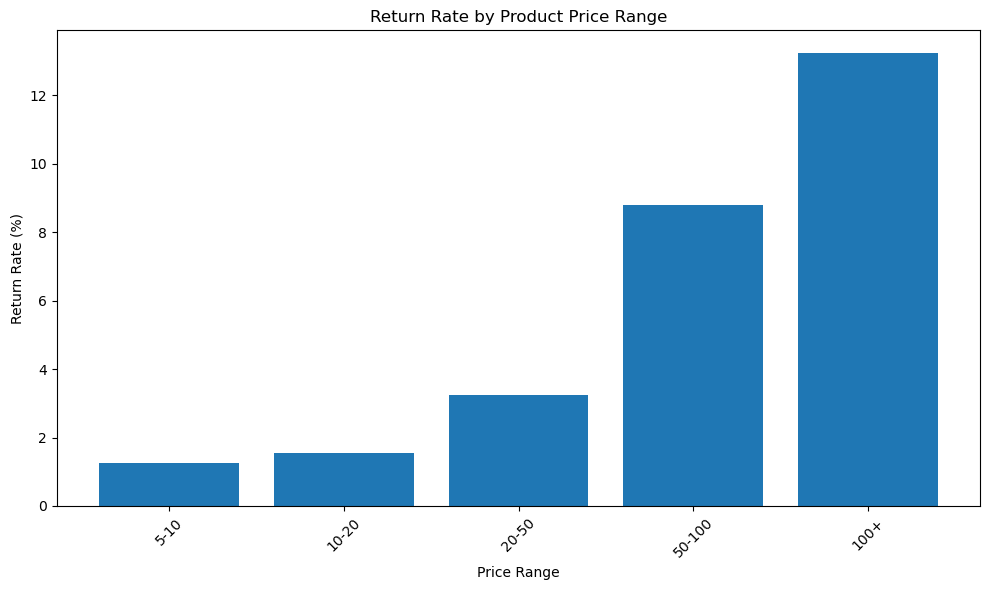

In [12]:
plt.figure(figsize=(10, 6))

plt.bar(
    price_analysis["Price_Range"].astype(str),
    price_analysis["Return_Rate_Percentage"]
)

plt.xlabel("Price Range")

plt.ylabel("Return Rate (%)")

plt.title("Return Rate by Product Price Range")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [13]:
output_path = r"C:\Users\91934\OneDrive\Desktop\DA\PROJECT\docs\price_return_analysis.csv"

price_analysis.to_csv(
    output_path,
    index=False
)

print("Analysis saved successfully.")

Analysis saved successfully.


## Findings

- The dataset does not contain discount percentage information, so the exact relationship between discounts and return probability could not be measured.
- Cancelled or returned transactions were identified using transaction numbers starting with "C".
- Product prices were grouped into ranges to compare return behavior across different price levels.
- Return probability was calculated for each price range.
- The price range with the highest return probability was identified as the potential breaking point.
- The correlation between product price and return behavior was calculated to evaluate whether higher or lower prices were associated with increased returns.